# Housing Price Prediction Model

This notebook loads the preprocessed data, performs additional feature engineering (ratios and interactions), and trains several models to predict housing prices.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Model Imports
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV, train_test_split # Added train_test_split here
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set plot style and suppress warnings
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Processed Data

We load the `training_processed.csv` and `test_processed.csv` files created by the preprocessing script.

In [48]:
# Load the processed data
# The paths are relative to this notebook's location (in the 'notebooks' folder)
try:
    train_df = pd.read_csv("../data/processed_data/training_processed.csv")
    test_df = pd.read_csv("../data/processed_data/test_processed.csv")
    
    print(f"Training data shape: {train_df.shape}")
    print(f"Test data shape: {test_df.shape}")
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("\nPlease make sure you have run the 'preprocess_data.py' script successfully.")

Training data shape: (48775, 33)
Test data shape: (12194, 33)


Majority of the data cleaning and preprocessing was completed using this script. Here is a summary of all cleaning steps we've implemented:

1. Geospatial Feature Encoding: Converts city and state into latitude and longitude to create powerful, low-dimensional features.
2. Create the 'is_near_trader_joes' feature if a zip code is less than or equal to 25 miles away from a Traders Joes.
3. Create the 'min_distance_to_tj' feature representing the minimum distance from each property to the nearest Trader Joe's.
4. Filters the data to only include properties from California, Texas, Florida, Washington, and New York and with a previous sale date in 2022.
5. Filters data to only include zip codes with population density > 94.
6. Removes extreme price outliers using the IQR method.
7. Imputation for missing lot size based on median lot size.
8. Imputation for missing house size based on median house size
9. Imputation for missing bed/bath counts based on median bed/bath counts.
10. Imputation for missing prices based on bed/bath count.
11. Create distance bins and directional features for Trader Joe's proximity 
12. Scaling and encoding using RobustScaler and OneHotEncoder and included the original, unscaled numeric columns for reference/visualization later.
13. A random 80/20 split for training and testing.

## 2. Separate Original Features (X) and Target (y)

First, we separate the features as loaded from the CSV, before adding engineered ones.

In [49]:
# Define the target variable
target_col = 'price'

# Identify feature columns from the CSV
original_feature_cols = [col for col in train_df.columns if col != target_col and not col.endswith('_original')]

# Separate features and target
X_train_orig = train_df[original_feature_cols]
y_train = train_df[target_col]

X_test_orig = test_df[original_feature_cols]
y_test = test_df[target_col]

print(f"Original number of features: {len(original_feature_cols)}")
print(f"Target variable: {target_col}")

Original number of features: 21
Target variable: price


## 3. Feature Engineering: Ratios and Interactions

Create new features based on existing ones. We need the '_original' columns for these calculations as the others are scaled.

In [50]:
# --- Create features on Training Data ---
X_train = X_train_orig.copy()

# Ratios (using original, unscaled values)
# Handle potential division by zero: replace inf with NaN, then impute NaN (e.g., with 0 or median)
X_train['house_size_per_bed'] = (train_df['house_size_original'] / train_df['bed_original']).replace([np.inf, -np.inf], np.nan).fillna(0)
X_train['house_size_per_bath'] = (train_df['house_size_original'] / train_df['bath_original']).replace([np.inf, -np.inf], np.nan).fillna(0)
X_train['lot_size_per_house_size'] = (train_df['acre_lot_original'] / train_df['house_size_original']).replace([np.inf, -np.inf], np.nan).fillna(0)

# Interaction
X_train['bed_bath_interaction'] = train_df['bed_original'] * train_df['bath_original']

# --- Create features on Test Data --- 
# Use original unscaled values from test_df for consistency
X_test = X_test_orig.copy()

# Ratios
X_test['house_size_per_bed'] = (test_df['house_size_original'] / test_df['bed_original']).replace([np.inf, -np.inf], np.nan).fillna(0)
X_test['house_size_per_bath'] = (test_df['house_size_original'] / test_df['bath_original']).replace([np.inf, -np.inf], np.nan).fillna(0)
X_test['lot_size_per_house_size'] = (test_df['acre_lot_original'] / test_df['house_size_original']).replace([np.inf, -np.inf], np.nan).fillna(0)

# Interaction
X_test['bed_bath_interaction'] = test_df['bed_original'] * test_df['bath_original']

# --- Final Feature List ---
engineered_feature_cols = ['house_size_per_bed', 'house_size_per_bath', 'lot_size_per_house_size', 'bed_bath_interaction']
feature_cols = original_feature_cols + engineered_feature_cols

# --- Scale the New Features --- 
# Since the original features were scaled, we should scale the new ones too.
# We'll fit a scaler on the training data's new features and transform both train and test.
from sklearn.preprocessing import RobustScaler
scaler_eng = RobustScaler()
X_train[engineered_feature_cols] = scaler_eng.fit_transform(X_train[engineered_feature_cols])
X_test[engineered_feature_cols] = scaler_eng.transform(X_test[engineered_feature_cols]) # Use transform only for test data

print(f"Total number of features after engineering: {len(feature_cols)}")
print("Engineered features added and scaled.")
print("\nFirst 5 feature names:", feature_cols[:5])
print("Last 5 feature names:", feature_cols[-5:])

Total number of features after engineering: 25
Engineered features added and scaled.

First 5 feature names: ['bed', 'bath', 'acre_lot', 'house_size', 'latitude']
Last 5 feature names: ['month_sold', 'house_size_per_bed', 'house_size_per_bath', 'lot_size_per_house_size', 'bed_bath_interaction']


## 4. Model Evaluation Setup

Store results and define an evaluation function.

In [51]:
model_results = {}
model_predictions = {}
model_objects = {}

def evaluate_model(name, model, X_test, y_test):
    """Calculates R2, RMSE, and MAE and stores them."""
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    model_results[name] = {'R²': r2, 'RMSE': rmse, 'MAE': mae}
    model_predictions[name] = y_pred
    model_objects[name] = model
    
    print(f"--- {name} Results ---")
    print(f"R²: {r2:.4f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"MAE: ${mae:,.2f}")

## 5. Model 1: Baseline Linear Models

Test standard and regularized linear models.

In [52]:
print("Training Baseline Linear Models...")

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
evaluate_model("Linear Regression", lr_model, X_test, y_test)

# Ridge Regression (L2 Regularization)
ridge_model = Ridge(random_state=42)
ridge_model.fit(X_train, y_train)
evaluate_model("Ridge Regression", ridge_model, X_test, y_test)

# Lasso Regression (L1 Regularization)
lasso_model = Lasso(random_state=42)
lasso_model.fit(X_train, y_train)
evaluate_model("Lasso Regression", lasso_model, X_test, y_test)

# ElasticNet (L1 + L2 Regularization)
elastic_model = ElasticNet(random_state=42)
elastic_model.fit(X_train, y_train)
evaluate_model("ElasticNet", elastic_model, X_test, y_test)

Training Baseline Linear Models...
--- Linear Regression Results ---
R²: 0.4920
RMSE: $292,094.37
MAE: $220,259.47
--- Ridge Regression Results ---
R²: 0.4923
RMSE: $292,018.84
MAE: $219,944.35
--- Lasso Regression Results ---
R²: 0.4915
RMSE: $292,244.12
MAE: $219,653.57
--- ElasticNet Results ---
R²: 0.3648
RMSE: $326,646.47
MAE: $249,512.33


## 6. Model 2: Random Forest w/ Hyperparameter Tuning

Use `RandomizedSearchCV` to find better hyperparameters.

In [53]:
print("--- Training Tuned Random Forest ---")

# Define the parameter distribution
param_dist_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 3, 5],
    'min_samples_split': [2, 5, 10]
}

# Initialize Randomized Search
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_search = RandomizedSearchCV(estimator=rf, 
                             param_distributions=param_dist_rf, 
                             n_iter=10, # Number of parameter settings sampled
                             cv=3, # Number of cross-validation folds
                             verbose=1, 
                             random_state=42, 
                             n_jobs=-1) # Use all available CPU cores

print("Fitting RandomizedSearchCV for Random Forest...")
rf_search.fit(X_train, y_train)

print(f"Best parameters found: {rf_search.best_params_}")
best_rf = rf_search.best_estimator_
evaluate_model("Tuned Random Forest", best_rf, X_test, y_test)

--- Training Tuned Random Forest ---
Fitting RandomizedSearchCV for Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters found: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_depth': None}
--- Tuned Random Forest Results ---
R²: 0.8172
RMSE: $175,228.57
MAE: $112,350.87


## 7. Model 3: Gradient Boosting w/ Hyperparameter Tuning

Tune `HistGradientBoostingRegressor`.

In [54]:
print("--- Training Tuned HistGradientBoostingRegressor ---")

# Define parameter distribution
param_dist_hgb = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 200, 300, 500],
    'max_leaf_nodes': [20, 31, 40, 50],
    'l2_regularization': [0, 0.01, 0.1, 1]
}

# Initialize Randomized Search
hgb = HistGradientBoostingRegressor(random_state=42)
hgb_search = RandomizedSearchCV(estimator=hgb, 
                              param_distributions=param_dist_hgb, 
                              n_iter=10, 
                              cv=3, 
                              verbose=1, 
                              random_state=42, 
                              n_jobs=-1)

print("Fitting RandomizedSearchCV for HistGradientBoosting...")
hgb_search.fit(X_train, y_train)

print(f"Best parameters found: {hgb_search.best_params_}")
best_hgb = hgb_search.best_estimator_
evaluate_model("Tuned HistGradientBoost", best_hgb, X_test, y_test)

--- Training Tuned HistGradientBoostingRegressor ---
Fitting RandomizedSearchCV for HistGradientBoosting...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters found: {'max_leaf_nodes': 50, 'max_iter': 500, 'learning_rate': 0.1, 'l2_regularization': 0.1}
--- Tuned HistGradientBoost Results ---
R²: 0.8287
RMSE: $169,633.37
MAE: $112,347.21


## 8. Final Model Comparison

In [55]:
results_df = pd.DataFrame(model_results).T.sort_values(by='R²', ascending=False)

print("--- Model Performance Summary ---")
display(results_df.style.format({
    'R²': '{:.4f}',
    'RMSE': '${:,.2f}',
    'MAE': '${:,.2f}'
}))

--- Model Performance Summary ---


,R²,RMSE,MAE
Tuned HistGradientBoost,0.8287,"$169,633.37","$112,347.21"
Tuned Random Forest,0.8172,"$175,228.57","$112,350.87"
Ridge Regression,0.4923,"$292,018.84","$219,944.35"
Linear Regression,0.4920,"$292,094.37","$220,259.47"
Lasso Regression,0.4915,"$292,244.12","$219,653.57"
ElasticNet,0.3648,"$326,646.47","$249,512.33"


## 9. Visual Evaluation of Best Model

--- Visualizing Best Model: Tuned HistGradientBoost ---


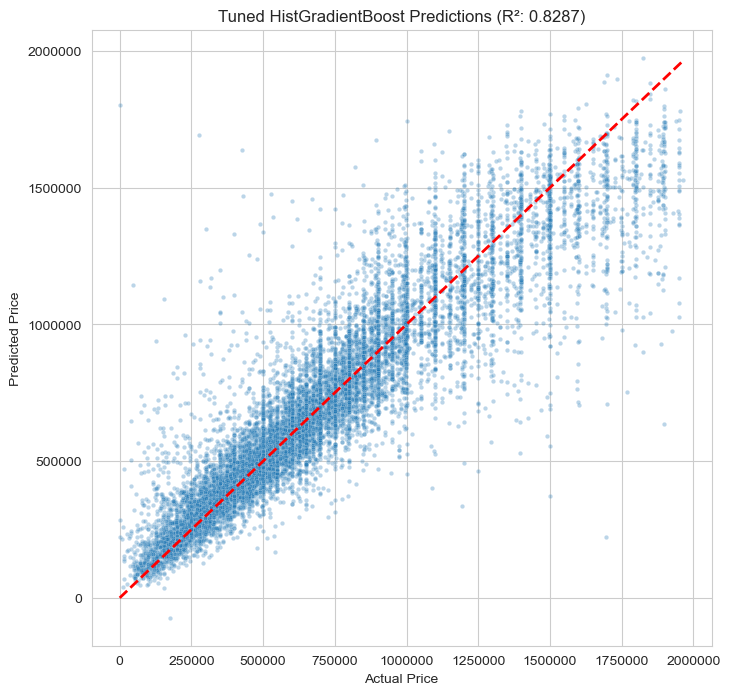

In [56]:
# Find best model name
best_model_name = results_df.index[0]
y_pred_best = model_predictions[best_model_name]
best_model_r2 = results_df.loc[best_model_name, 'R²']

print(f"--- Visualizing Best Model: {best_model_name} ---")

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', linewidth=2)
plt.title(f"{best_model_name} Predictions (R²: {best_model_r2:.4f})")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.ticklabel_format(style='plain', axis='both')
plt.show()

## 10. Feature Analysis

Examine feature importances/coefficients from the best models.

--- Tuned Random Forest Feature Importances ---


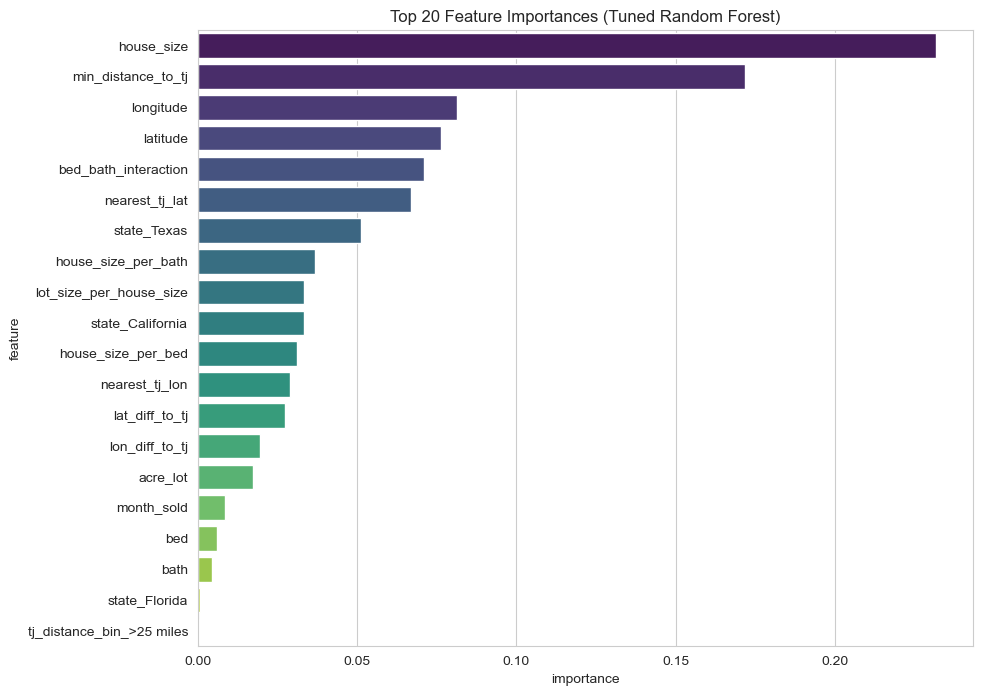

In [57]:
print("--- Tuned Random Forest Feature Importances ---")

# Check if Tuned Random Forest exists before getting importances
if 'Tuned Random Forest' in model_objects:
    rf_importances = model_objects['Tuned Random Forest'].feature_importances_
    rf_importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf_importances
    }).sort_values(by='importance', ascending=False)
    
    # Plot top features
    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='feature', data=rf_importance_df.head(20), palette='viridis')
    plt.title("Top 20 Feature Importances (Tuned Random Forest)")
    plt.show()
else:
    print("Tuned Random Forest model object not found.")

--- Ridge Regression Coefficients ---


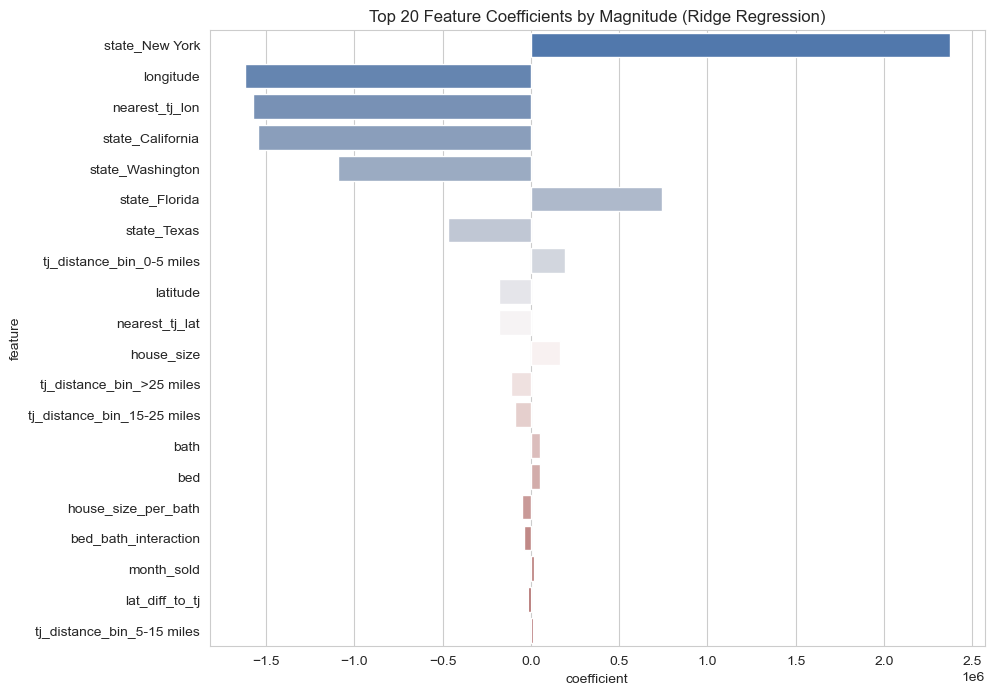

In [58]:
print("--- Ridge Regression Coefficients ---")

# Check if Ridge exists before getting coefficients
if 'Ridge Regression' in model_objects:
    ridge_coeffs = model_objects['Ridge Regression'].coef_
    ridge_coeff_df = pd.DataFrame({
        'feature': feature_cols,
        'coefficient': ridge_coeffs
    }).sort_values(by='coefficient', key=abs, ascending=False) # Sort by absolute value
    
    # Plot top coefficients (absolute value)
    plt.figure(figsize=(10, 8))
    sns.barplot(x='coefficient', y='feature', data=ridge_coeff_df.head(20), palette='vlag')
    plt.title("Top 20 Feature Coefficients by Magnitude (Ridge Regression)")
    plt.show()
else:
    print("Ridge Regression model object not found.")

## 11. Save Predictions 

In [59]:
print("--- Saving Test Set with Predictions ---")
import os
# Use the test_df_output which contains the original features + target
test_df_final = test_df.copy()
    
# Add the predicted price column from the best GBM model
test_df_final['predicted_price'] = model_predictions['Tuned HistGradientBoost']
    
# Define output directory and file path
output_dir = "../data/output_data"
output_file = os.path.join(output_dir, "test_data_with_predictions.csv")
    
# Save the dataframe to CSV
try:
    test_df_final.to_csv(output_file, index=False)
    print(f"Successfully saved test data with predictions to: {output_file}")
except Exception as e:
        print(f"Error saving file: {e}")  

--- Saving Test Set with Predictions ---
Successfully saved test data with predictions to: ../data/output_data/test_data_with_predictions.csv
